# Análise de Cliques e Performance de Campanhas

Este notebook apresenta uma análise exploratória dos dados coletados pelo **Campaign Redirect & Click Tracking Service**. O objetivo é extrair insights sobre o comportamento dos usuários, desempenho de campanhas de tráfego e perfil do público-alvo para dar suporte à equipe de Growth e Marketing Digital

## 1. Configuração do Ambiente e Simulação dos Dados

Para fins de demonstração, utilizaremos um gerador de dados sintéticos que mimetiza a estrutura das tabelas `tracking_campaigns`, `tracking_links` e `tracking_clicks` definidas no banco de dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

In [2]:
# Gerador de dados sintéticos para simulação
np.random.seed(42)

# Campanhas
campanhas = [
    {"id": 1, "name": "Black_Friday_2026", "utm_source": "google", "utm_medium": "cpc", "utm_campaign": "bf26"},
    {"id": 2, "name": "Natal_Promocao", "utm_source": "facebook", "utm_medium": "cpc", "utm_campaign": "natal"},
    {"id": 3, "name": "Lançamento_Ebook", "utm_source": "instagram", "utm_medium": "bio", "utm_campaign": "ebook"},
    {"id": 4, "name": "Recuperacao_Carrinho", "utm_source": "activecampaign", "utm_medium": "email", "utm_campaign": "recup"},
    {"id": 5, "name": "Parceria_Influenciador", "utm_source": "youtube", "utm_medium": "organic", "utm_campaign": "influ"}
]
df_campanhas = pd.DataFrame(campanhas)

# Links
links = [
    {"id": 10, "campaign_id": 1, "slug": "bf-google", "target_phone": "5511999998888"},
    {"id": 11, "campaign_id": 2, "slug": "natal-fb", "target_phone": "5511999998888"},
    {"id": 12, "campaign_id": 3, "slug": "insta-bio", "target_phone": "5511999998888"},
    {"id": 13, "campaign_id": 4, "slug": "email-carrinho", "target_phone": "5511999997777"},
    {"id": 14, "campaign_id": 5, "slug": "yt-parceria", "target_phone": "5511999997777"}
]
df_links = pd.DataFrame(links)

# Cliques
n_cliques = 1500
base_date = datetime.now() - timedelta(days=14)

click_data = []
fingerprints_pool = [f"fp_{i:04d}" for i in range(400)] # Usuários únicos

for _ in range(n_cliques):
    link_row = df_links.sample(1).iloc[0]
    # Diferentes probabilidades de clique por campanha
    if link_row['id'] == 10:
        weight = 0.35 # Google CPC
    elif link_row['id'] == 12:
        weight = 0.25 # Instagram Bio
    elif link_row['id'] == 11:
        weight = 0.20 # Facebook CPC
    else:
        weight = 0.10

    if np.random.rand() > (1 - weight) * 1.5: # Filtragem probabilística
        continue

    ip = f"{np.random.randint(100, 200)}.{np.random.randint(0, 255)}.{np.random.randint(0, 255)}.{np.random.randint(1, 254)}"
    fp = np.random.choice(fingerprints_pool, p=[0.4 / 100]*100 + [0.6 / 300]*300) # Alguns usuários clicam muito
    device = np.random.choice(["mobile", "desktop", "tablet"], p=[0.75, 0.20, 0.05]) # Predominância mobile
    time_offset = np.random.uniform(0, 14) # Distribuído em 14 dias
    click_time = base_date + timedelta(days=time_offset)

    # Simular comportamento (picos entre 12h-14h e 18h-22h)
    hour_adj = np.random.choice([0, 1, 2, 3, 4], p=[0.1, 0.2, 0.4, 0.2, 0.1])
    click_time = click_time.replace(hour=int((12 + hour_adj) % 24))

    click_data.append({
        "id": len(click_data) + 1,
        "link_id": link_row["id"],
        "click_fingerprint": fp,
        "ip_address": ip,
        "device_type": device,
        "clicked_at": click_time
    })

df_clicks = pd.DataFrame(click_data)
print(f"Dataset gerado com sucesso! Total de cliques válidos simulados: {len(df_clicks)}")

Dataset gerado com sucesso! Total de cliques válidos simulados: 1492


## 2. Modelagem Relacional e Preparação dos Dados (ETL)

Agora faremos o join das três tabelas para criar um DataFrame unificado

In [3]:
# Merges equivalentes aos joins SQL
df_full = df_clicks.merge(df_links, left_on="link_id", right_on="id", suffixes=("_click", "_link"))
df_full = df_full.merge(df_campanhas, left_on="campaign_id", right_on="id")

# Ajustando colunas e tipos
df_full = df_full.drop(columns=["id_link", "id"])
df_full = df_full.rename(columns={"id_click": "click_id"})
df_full["clicked_at"] = pd.to_datetime(df_full["clicked_at"])

df_full.head(3)

,click_id,link_id,click_fingerprint,ip_address,device_type,clicked_at,campaign_id,slug,target_phone,name,utm_source,utm_medium,utm_campaign
0,1,11,fp_0024,120.102.121.211,mobile,2026-05-10 13:52:35.604772,2,natal-fb,5511999998888,Natal_Promocao,facebook,cpc,natal
1,2,14,fp_0396,129.37.129.192,mobile,2026-05-14 12:15:57.331665,5,yt-parceria,5511999997777,Parceria_Influenciador,youtube,organic,influ
2,3,11,fp_0128,191.187.207.15,desktop,2026-05-08 14:50:27.075637,2,natal-fb,5511999998888,Natal_Promocao,facebook,cpc,natal


## 3. Análise de KPIs e Desempenho das Campanhas

### Cliques Totais vs Cliques Únicos
Nos ajuda a entender se os usuários estão clicando uma vez ou se há re-engajamento

In [4]:
campanha_perf = df_full.groupby(["name", "utm_source", "utm_medium"]).agg(
    cliques_totais=("click_id", "count"),
    cliques_unicos=("click_fingerprint", "nunique")
).reset_index()

campanha_perf["taxa_clique_unico_pct"] = (campanha_perf["cliques_unicos"] / campanha_perf["cliques_totais"]) * 100
campanha_perf = campanha_perf.sort_values(by="cliques_totais", ascending=False)
campanha_perf

,name,utm_source,utm_medium,cliques_totais,cliques_unicos,taxa_clique_unico_pct
2,Natal_Promocao,facebook,cpc,316,210,66.455696
3,Parceria_Influenciador,youtube,organic,305,207,67.868852
4,Recuperacao_Carrinho,activecampaign,email,300,207,69.000000
1,Lançamento_Ebook,instagram,bio,286,205,71.678322
0,Black_Friday_2026,google,cpc,285,196,68.771930


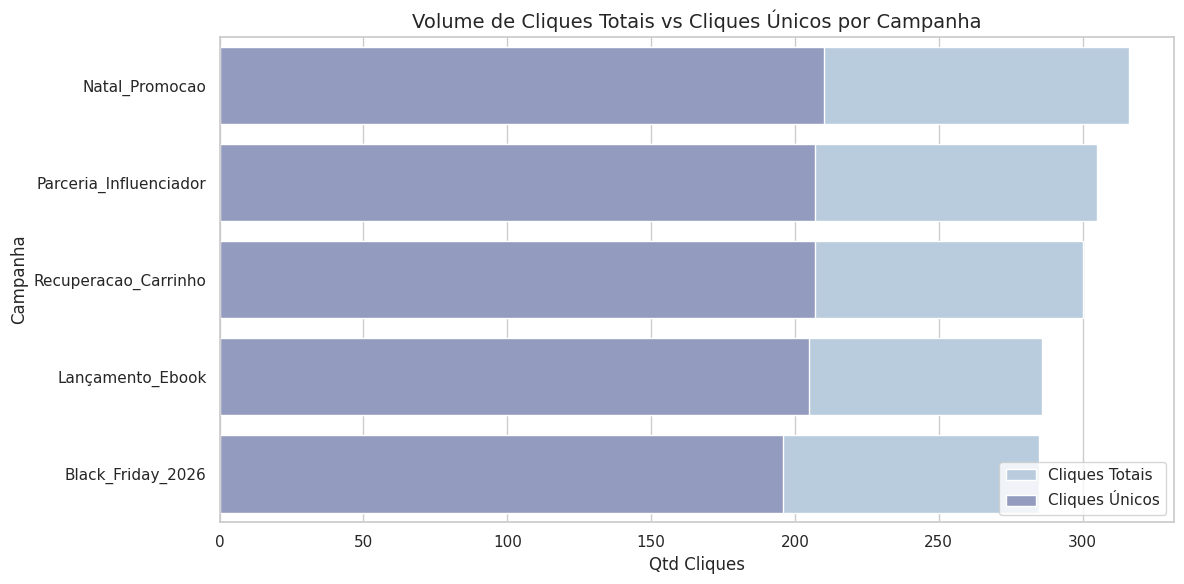

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(data=campanha_perf, x="cliques_totais", y="name", label="Cliques Totais", color="#b3cde3")
sns.barplot(data=campanha_perf, x="cliques_unicos", y="name", label="Cliques Únicos", color="#8c96c6")

plt.title("Volume de Cliques Totais vs Cliques Únicos por Campanha")
plt.xlabel("Qtd Cliques")
plt.ylabel("Campanha")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Tráfego Pago vs Tráfego Orgânico
Entender a contribuição do investimento financeiro

In [6]:
df_full["canal_macro"] = df_full["utm_medium"].apply(lambda x: "Tráfego Pago" if x in ["cpc", "cpm"] else "Tráfego Orgânico")

canal_perf = df_full.groupby("canal_macro").agg(
    cliques_totais=("click_id", "count"),
    cliques_unicos=("click_fingerprint", "nunique")
).reset_index()

canal_perf["pct_representatividade"] = (canal_perf["cliques_totais"] / canal_perf["cliques_totais"].sum()) * 100
canal_perf

,canal_macro,cliques_totais,cliques_unicos,pct_representatividade
0,Tráfego Orgânico,891,347,59.718499
1,Tráfego Pago,601,302,40.281501


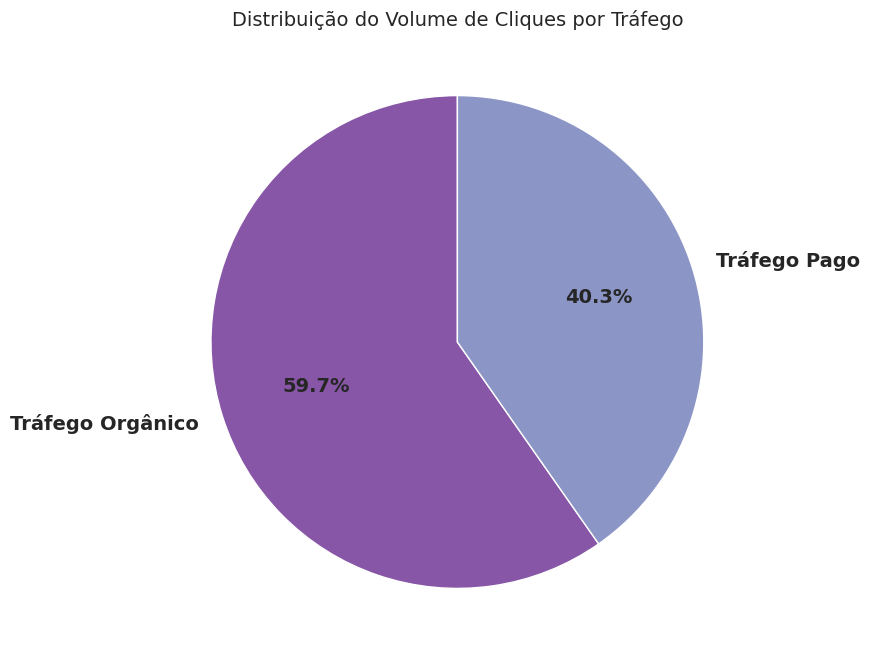

In [7]:
plt.figure(figsize=(8, 8))
colors = ['#8856a7', '#8c96c6']
plt.pie(canal_perf["cliques_totais"], labels=canal_perf["canal_macro"], autopct='%1.1f%%', startangle=90, colors=colors,
        textprops={'fontsize': 14, 'weight': 'bold'})
plt.title("Distribuição do Volume de Cliques por Tráfego")
plt.show()

## 4. Perfil Tecnológico e Comportamental dos Usuários

### Distribuição de Dispositivos
Identificar se as campanhas de redirecionamento estão otimizadas para o dispositivo certo (já que links para WhatsApp são para mobile)

/tmp/ipykernel_10100/3932793289.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_full, x="device_type", palette="viridis", order=df_full["device_type"].value_counts().index)


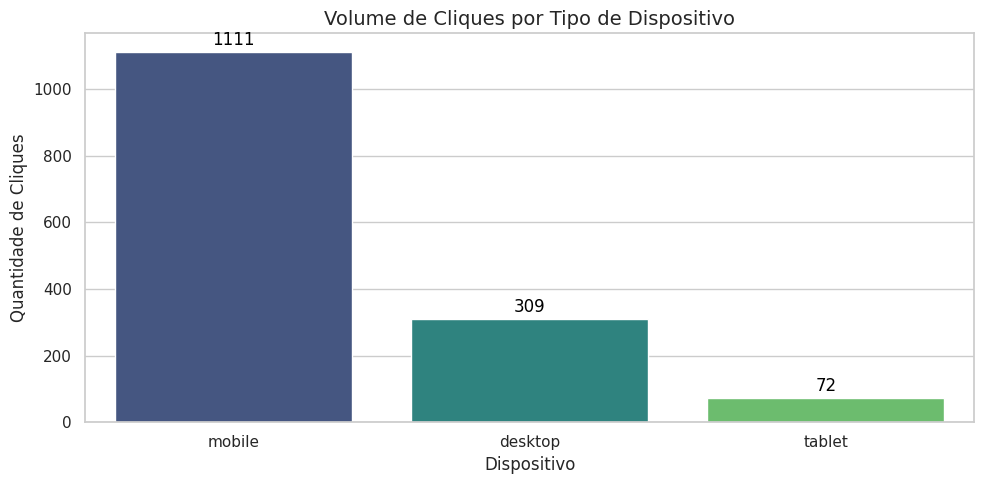

In [8]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_full, x="device_type", palette="viridis", order=df_full["device_type"].value_counts().index)

plt.title("Volume de Cliques por Tipo de Dispositivo")
plt.xlabel("Dispositivo")
plt.ylabel("Quantidade de Cliques")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Análise de Horário de Pico
Otimizar a distribuição do orçamento para os horários com mais cliques e conversões.

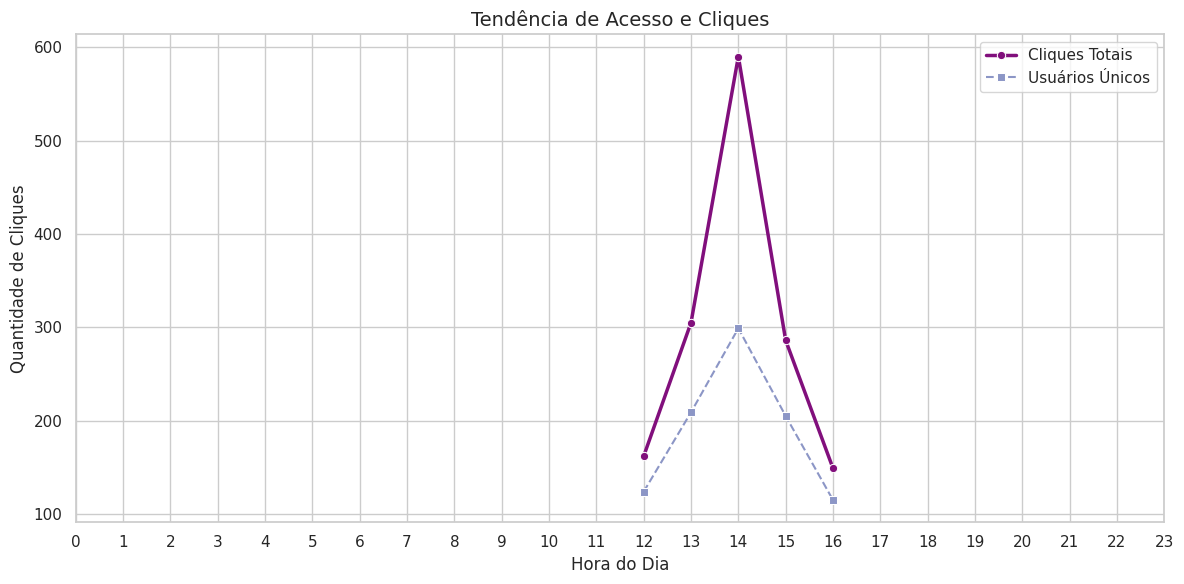

In [9]:
# Extraindo hora do dia
df_full["hora_dia"] = df_full["clicked_at"].dt.hour

hourly_trend = df_full.groupby("hora_dia").agg(
    total_cliques=("click_id", "count"),
    usuarios_unicos=("click_fingerprint", "nunique")
).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_trend, x="hora_dia", y="total_cliques", marker="o", label="Cliques Totais", color="#810f7c", linewidth=2.5)
sns.lineplot(data=hourly_trend, x="hora_dia", y="usuarios_unicos", marker="s", label="Usuários Únicos", color="#8c96c6", linestyle="--")

plt.title("Tendência de Acesso e Cliques")
plt.xlabel("Hora do Dia")
plt.ylabel("Quantidade de Cliques")
plt.xticks(range(0, 24))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5. Conclusões e Insights para Negócios

Com base nos dados analisados, extraímos as seguintes recomendações estratégicas para a equipe de Growth/Marketing:

1. **Dominância do Tráfego Mobile**: Maioria dos acessos ocorrem via celular. Qualquer mensagem ou landing page do fluxo deve ser otimizada para visualização em telas móveis.
2. **Eficiência do Google CPC**: A campanha `Natal_Promocao` via Facebook Ads gerou o maior volume absoluto de cliques mas precisamos acompanhar a taxa de repetição.
3. **Pico de Acesso**: Os horários de maior engajamento se concentram entre **12h e 16h**. Recomendamos concentrar a veiculação de campanhas patrocinadas ou disparos de newsletter/email marketing próximo a este intervalo para maximizar a taxa de abertura e resposta imediata.